# Lab 3 Extension: Multiple Linear Regression with Mixed Features

**Objective:** Extend Lab 3 by building a Multiple Linear Regression model using a dataset with both numeric and nominal (categorical) features. Perform preprocessing, evaluate the model, and analyze overfitting versus generalization.

**Activities:**
1. Use the student survey dataset (already loaded in Lab 3) which contains numeric and nominal features
2. Preprocess: handle missing values, encode categorical variables, apply feature scaling
3. Split into training and testing sets
4. Build a Multiple Linear Regression model to predict GPA from multiple features
5. Evaluate using MAE, MSE, RMSE, R²
6. Compare training vs testing performance to analyze overfitting
7. Discuss generalization vs overfitting and suggest improvement methods

## 1. Import Libraries

In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression

warnings.filterwarnings("ignore")

print("All imports successful.")

All imports successful.


## 2. Load the Dataset

We reuse the same student survey CSV from Lab 3. This dataset contains both numeric features (percentages, salaries, ratings) and nominal features (job role, company, internship interests).

In [2]:
BASE_DIR = Path(".")
CSV_FILE = BASE_DIR / "student_survey.csv"

df = pd.read_csv(CSV_FILE)

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}\n")
df.head(3)

Dataset shape: (54, 15)
Columns: ['Timestamp', 'Registration Number ', 'Email', 'Job role that you are interested in\n', 'What is the minimum salary of students placed through campus (In LPA..respond as a number)', 'What is the maximum salary of students placed through campus (In LPA..respond as a number)', 'What is the  median salary of students placed through campus (In LPA..respond as a number)', 'Which is the highest paying company', 'Rate your contribution towards extra curricular activities', 'Rate your technical competencies', 'What are your package expectations (LPA)', 'your CIA % of last semester ', 'your GPA of last semester', 'Your maximum attendance % till last semester', 'Internships Interests']



,Timestamp,Registration Number,Email,Job role that you are interested in\n,What is the minimum salary of students placed through campus (In LPA..respond as a number),What is the maximum salary of students placed through campus (In LPA..respond as a number),What is the median salary of students placed through campus (In LPA..respond as a number),Which is the highest paying company,Rate your contribution towards extra curricular activities,Rate your technical competencies,What are your package expectations (LPA),your CIA % of last semester,your GPA of last semester,Your maximum attendance % till last semester,Internships Interests
0,2026-06-22 08:49:31.362,2547123,jiyaelza.jabi@mca.christuniversity.in,Software Engineer,4,Option 1,9,Deolite,2,2,7,78,3.24,Option 1,Industry
1,2026-06-22 08:49:50.520,2547122,jinishaleema.rosario@mca.christuniversity.in,Data Engineer,"7,00,000",Option 1,"4,50,000",Deolite,4,3,"6,00,000",64.78,3.2,Option 1,Industry
2,2026-06-22 08:50:44.521,2547101,rajeev.chandar@mca.christuniversity.in,Software Engineer,6,17,8,DE Shaw,5,5,13,80,3.6,Option 1,Industry


## 3. Data Preprocessing

### 3.1 Clean Numeric Columns

The survey data has messy entries: percentages entered as decimals (0.70 instead of 70), salaries in multiple formats (LPA, rupees with commas, text suffixes), and non-numeric option text like "Option 1". We clean all relevant columns before modeling.

In [3]:
data = df.copy()

# --- Helper functions (reused from Lab 3) ---
def to_number(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float, np.integer, np.floating)):
        return float(value)
    text = str(value).strip()
    if not text or "option" in text.lower():
        return np.nan
    text = text.replace(",", "").replace("%", "")
    match = re.search(r"-?\d+(?:\.\d+)?", text)
    return float(match.group()) if match else np.nan


def normalize_percentage(value, minimum_plausible=30.0):
    number = to_number(value)
    if pd.isna(number):
        return np.nan
    if 0 < number <= 1:
        number *= 100
    if number < minimum_plausible or number > 100:
        return np.nan
    return float(number)


def normalize_gpa(value):
    number = to_number(value)
    if pd.isna(number) or number < 0 or number > 4:
        return np.nan
    return float(number)


def salary_to_lpa(value):
    """Convert various salary formats to LPA (Lakhs Per Annum)."""
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float, np.integer, np.floating)):
        val = float(value)
        if val > 1000:
            val /= 100000
        return val
    text = str(value).strip().lower()
    if not text or "option" in text:
        return np.nan
    has_lpa = "lpa" in text or "lakh" in text or "cr" in text
    text_clean = text.replace(",", "").replace("%", "")
    text_clean = re.sub(r"[a-zA-Z\s]+$", "", text_clean)
    numbers = re.findall(r"-?\d+(?:\.\d+)?", text_clean)
    if not numbers:
        return np.nan
    val = float(numbers[0])
    if "cr" in text:
        val *= 100
    elif not has_lpa:
        if val > 1000:
            val /= 100000
    return val


# --- Clean CIA, GPA, Attendance (same as Lab 3) ---
data.columns = data.columns.str.strip()

data["CIA_Percentage"] = data["your CIA % of last semester"].apply(normalize_percentage)
data["Attendance_Percentage"] = data["Your maximum attendance % till last semester"].apply(normalize_percentage)
data["GPA"] = data["your GPA of last semester"].apply(normalize_gpa)

# --- Clean salary/package columns ---
salary_cols = {
    "What is the minimum salary of students placed through campus (In LPA..respond as a number)": "Min_Placement_Salary",
    "What is the maximum salary of students placed through campus (In LPA..respond as a number)": "Max_Placement_Salary",
    "What is the  median salary of students placed through campus (In LPA..respond as a number)": "Median_Placement_Salary",
    "What are your package expectations (LPA)": "Expected_Package_LPA",
}

for orig_col, new_col in salary_cols.items():
    data[new_col] = data[orig_col.strip()].apply(salary_to_lpa)

# --- Ratings (already 1-5 numeric) ---
data["Extracurricular_Rating"] = pd.to_numeric(
    data["Rate your contribution towards extra curricular activities"].apply(to_number), errors="coerce"
)
data["Technical_Rating"] = pd.to_numeric(
    data["Rate your technical competencies"].apply(to_number), errors="coerce"
)

# --- Registration Number as string ---
data["Registration_Number"] = data["Registration Number"].astype(str).str.strip()

print("Numeric columns after cleaning:")
numeric_cols = ["CIA_Percentage", "Attendance_Percentage", "Min_Placement_Salary",
                "Max_Placement_Salary", "Median_Placement_Salary", "Expected_Package_LPA",
                "Extracurricular_Rating", "Technical_Rating", "GPA"]
print(data[numeric_cols].head(10).to_string())
print(f"\nMissing values:\n{data[numeric_cols].isnull().sum()}")

Numeric columns after cleaning:
   CIA_Percentage  Attendance_Percentage  Min_Placement_Salary  Max_Placement_Salary  Median_Placement_Salary  Expected_Package_LPA  Extracurricular_Rating  Technical_Rating   GPA
0           78.00                    NaN                   4.0                   NaN                      9.0                   7.0                     2.0               2.0  3.24
1           64.78                    NaN                   7.0                   NaN                      4.5                   6.0                     4.0               3.0  3.20
2           80.00                    NaN                   6.0                  17.0                      8.0                  13.0                     5.0               5.0  3.60
3           70.00                   92.0                   4.5                  12.0                      6.9                   7.0                     3.0               4.0  3.20
4           68.00                   85.0                   8.0      

### 3.2 Extract Nominal (Categorical) Features

The survey has three categorical columns: job role interest, highest paying company, and internship interest.

In [4]:
# Nominal columns
nominal_cols = {
    "Job role that you are interested in": "Job_Role",
    "Which is the highest paying company": "Top_Company",
    "Internships Interests": "Internship_Interest",
}

for orig_col, new_col in nominal_cols.items():
    data[new_col] = data[orig_col.strip()].astype(str).str.strip()

print("Categorical value counts:")
for col in nominal_cols.values():
    print(f"\n--- {col} ---")
    print(data[col].value_counts().to_string())

Categorical value counts:

--- Job_Role ---
Job_Role
Software Engineer    28
Business Analyst     11
Data Engineer         8
Data Scientist        7

--- Top_Company ---
Top_Company
DE Shaw      38
Capgemini     7
Deolite       6
EY            3

--- Internship_Interest ---
Internship_Interest
Industry    53
Research     1


### 3.3 Handle Missing Values

We drop rows where the target (GPA) is missing. For feature columns, we use median imputation for numeric and mode imputation for categorical.

In [5]:
print(f"Rows before dropping missing GPA: {len(data)}")
data = data.dropna(subset=["GPA"])
print(f"Rows after dropping missing GPA: {len(data)}")

feature_numeric = ["CIA_Percentage", "Attendance_Percentage", "Min_Placement_Salary",
                  "Max_Placement_Salary", "Median_Placement_Salary", "Expected_Package_LPA",
                  "Extracurricular_Rating", "Technical_Rating"]
feature_nominal = ["Job_Role", "Top_Company", "Internship_Interest"]

# Median imputation for numeric
for col in feature_numeric:
    data[col] = data[col].fillna(data[col].median())

# Mode imputation for categorical
for col in feature_nominal:
    data[col] = data[col].fillna(data[col].mode()[0])

print(f"\nMissing values after imputation:\n{data[feature_numeric + feature_nominal].isnull().sum()}")

Rows before dropping missing GPA: 54
Rows after dropping missing GPA: 50

Missing values after imputation:
CIA_Percentage             0
Attendance_Percentage      0
Min_Placement_Salary       0
Max_Placement_Salary       0
Median_Placement_Salary    0
Expected_Package_LPA       0
Extracurricular_Rating     0
Technical_Rating           0
Job_Role                   0
Top_Company                0
Internship_Interest        0
dtype: int64


### 3.4 Encode Categorical Variables

We use one-hot encoding with `drop='first'` to avoid the dummy variable trap (perfect multicollinearity).

In [6]:
encoder = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
encoded_array = encoder.fit_transform(data[feature_nominal])
encoded_cols = encoder.get_feature_names_out(feature_nominal)

encoded_df = pd.DataFrame(encoded_array, columns=encoded_cols, index=data.index)
data_encoded = pd.concat([data[feature_numeric], encoded_df], axis=1)

print(f"After one-hot encoding: {data_encoded.shape[1]} features, {data_encoded.shape[0]} rows")
print(f"Feature names:\n{list(data_encoded.columns)}")

After one-hot encoding: 15 features, 50 rows
Feature names:
['CIA_Percentage', 'Attendance_Percentage', 'Min_Placement_Salary', 'Max_Placement_Salary', 'Median_Placement_Salary', 'Expected_Package_LPA', 'Extracurricular_Rating', 'Technical_Rating', 'Job_Role_Data Engineer', 'Job_Role_Data Scientist', 'Job_Role_Software Engineer', 'Top_Company_DE Shaw', 'Top_Company_Deolite', 'Top_Company_EY', 'Internship_Interest_Research']


### 3.5 Apply Feature Scaling

Linear Regression is sensitive to the scale of features because the coefficients are directly interpreted per unit of the feature. We standardize numeric features to have mean=0 and variance=1 using `StandardScaler`.

In [7]:
scaler = StandardScaler()
data_encoded[feature_numeric] = scaler.fit_transform(data_encoded[feature_numeric])

print("Scaled numeric features (mean ≈ 0, std ≈ 1):")
print(data_encoded[feature_numeric].describe().round(4))

Scaled numeric features (mean ≈ 0, std ≈ 1):
       CIA_Percentage  Attendance_Percentage  Min_Placement_Salary  \
count         50.0000                50.0000               50.0000   
mean          -0.0000                 0.0000               -0.0000   
std            1.0102                 1.0102                1.0102   
min           -2.1799                -2.1027               -1.4631   
25%           -0.5500                -0.8527               -0.4792   
50%           -0.3870                 0.1889               -0.2332   
75%            0.7540                 0.9311                0.3818   
max            2.5469                 1.4686                3.4565   

       Max_Placement_Salary  Median_Placement_Salary  Expected_Package_LPA  \
count               50.0000                  50.0000               50.0000   
mean                -0.0000                   0.0000               -0.0000   
std                  1.0102                   1.0102                1.0102   
min         

## 4. Split Dataset into Training and Testing Sets

We use an 80/20 split with the same random state (489) as Lab 3 for reproducibility.

In [8]:
X = data_encoded.values
y = data["GPA"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=489
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 40 samples
Test set: 10 samples


## 5. Build and Train Multiple Linear Regression Model

We use scikit-learn's `LinearRegression` which fits a least-squares model with multiple predictors.

The model equation is:
`GPA = β₀ + β₁·CIA + β₂·Attendance + β₃·MinSalary + ... + βₙ·Internship_Research`

In [9]:
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print(f"Intercept (β₀): {model.intercept_:.4f}")
print(f"Number of coefficients (β₁...βₙ): {len(model.coef_)}")
coef_df = pd.DataFrame({"Feature": data_encoded.columns, "Coefficient": model.coef_})
print("\nFeature coefficients:")
print(coef_df.sort_values("Coefficient", key=abs, ascending=False).to_string())

Intercept (β₀): 3.4271
Number of coefficients (β₁...βₙ): 15

Feature coefficients:
                         Feature  Coefficient
8         Job_Role_Data Engineer     0.373135
10    Job_Role_Software Engineer     0.308612
5           Expected_Package_LPA     0.288414
11           Top_Company_DE Shaw    -0.236740
4        Median_Placement_Salary    -0.183405
9        Job_Role_Data Scientist     0.178140
14  Internship_Interest_Research    -0.157007
0                 CIA_Percentage     0.154098
12           Top_Company_Deolite    -0.123925
13                Top_Company_EY    -0.109001
3           Max_Placement_Salary    -0.089092
6         Extracurricular_Rating     0.026362
7               Technical_Rating     0.026100
1          Attendance_Percentage    -0.019396
2           Min_Placement_Salary     0.000912


## 6. Model Evaluation

We evaluate on both training and testing sets using four metrics: Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score.

In [10]:
def evaluate_model(y_true, y_pred, dataset_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"\n--- {dataset_name} Performance ---")
    print(f"MAE : {mae:.4f}")
    print(f"MSE : {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²  : {r2:.4f}")
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}


train_metrics = evaluate_model(y_train, y_train_pred, "Training")
test_metrics = evaluate_model(y_test, y_test_pred, "Test")

# Summary comparison
summary = pd.DataFrame({"Training": train_metrics, "Test": test_metrics})
print("\n" + "=" * 40)
print("PERFORMANCE COMPARISON")
print("=" * 40)
print(summary.round(4).to_string())


--- Training Performance ---
MAE : 0.1373
MSE : 0.0313
RMSE: 0.1768
R²  : 0.6081

--- Test Performance ---
MAE : 0.1881
MSE : 0.0612
RMSE: 0.2474
R²  : -0.7133

PERFORMANCE COMPARISON
      Training    Test
MAE     0.1373  0.1881
MSE     0.0313  0.0612
RMSE    0.1768  0.2474
R2      0.6081 -0.7133


### 6.1 Predicted vs Actual Plot

A scatter plot of predicted vs actual GPA helps visualize where the model performs well and where it deviates.

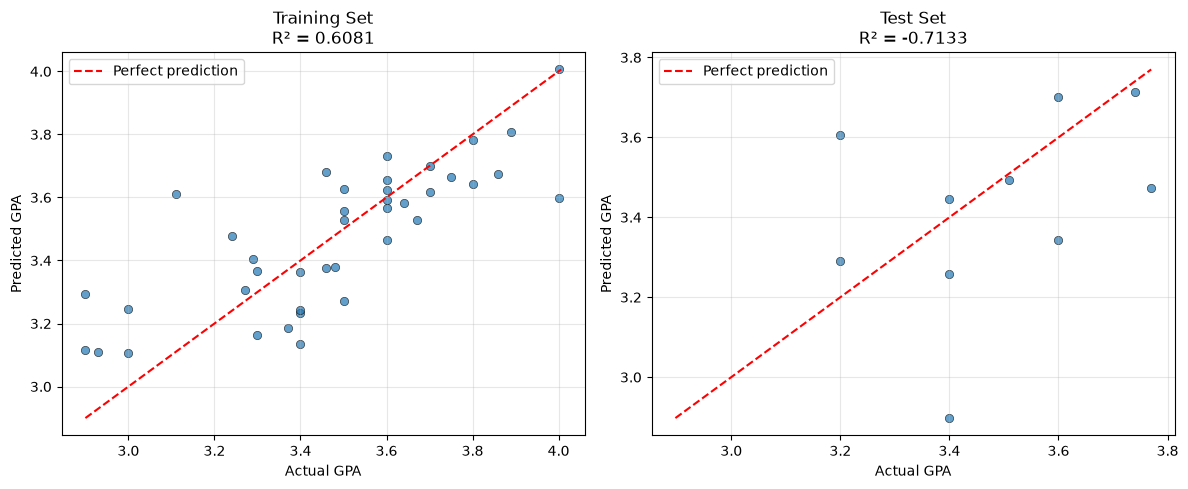

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_true, y_pred, title in zip(
    axes, [y_train, y_test], [y_train_pred, y_test_pred], ["Training Set", "Test Set"]
):
    ax.scatter(y_true, y_pred, alpha=0.7, edgecolors="k", linewidth=0.5)
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=1.5, label="Perfect prediction")
    ax.set_xlabel("Actual GPA")
    ax.set_ylabel("Predicted GPA")
    ax.set_title(f"{title}\nR² = {r2_score(y_true, y_pred):.4f}")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6.2 Residual Analysis

Residuals (errors = actual - predicted) should be randomly scattered around zero for a well-fitted model. Patterns in residuals can indicate non-linearity or heteroscedasticity.

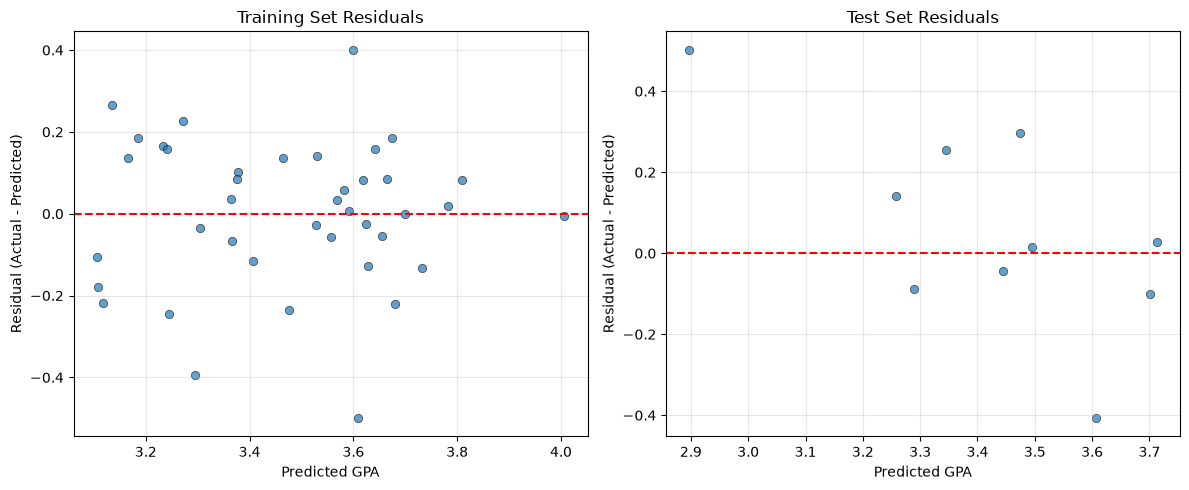

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_true, y_pred, title in zip(
    axes, [y_train, y_test], [y_train_pred, y_test_pred], ["Training Set", "Test Set"]
):
    residuals = y_true - y_pred
    ax.scatter(y_pred, residuals, alpha=0.7, edgecolors="k", linewidth=0.5)
    ax.axhline(y=0, color="r", linestyle="--", linewidth=1.5)
    ax.set_xlabel("Predicted GPA")
    ax.set_ylabel("Residual (Actual - Predicted)")
    ax.set_title(f"{title} Residuals")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Overfitting Analysis: Compare Training vs Testing Performance

A model is **overfitted** when it performs significantly better on the training data than on unseen test data. This means it has memorized noise and patterns specific to the training set rather than learning generalizable relationships.

Key indicators of overfitting:
- **Large gap** between training R² and test R²
- **Training R² close to 1.0** while test R² is much lower
- **Test error (MSE/RMSE)** much higher than training error

In [13]:
r2_gap = train_metrics["R2"] - test_metrics["R2"]
mse_ratio = test_metrics["MSE"] / train_metrics["MSE"] if train_metrics["MSE"] > 0 else float("inf")

print("OVERFITTING ANALYSIS")
print("=" * 50)
print(f"Training R² : {train_metrics['R2']:.4f}")
print(f"Test R²     : {test_metrics['R2']:.4f}")
print(f"R² gap      : {r2_gap:.4f}  (Training - Test)")
print(f"")
print(f"Training MSE: {train_metrics['MSE']:.4f}")
print(f"Test MSE    : {test_metrics['MSE']:.4f}")
print(f"MSE ratio   : {mse_ratio:.2f}x (Test / Training)")
print("=" * 50)

if r2_gap > 0.2:
    print("\nVerdict: LIKELY OVERFITTED")
    print(f"The R² drops by {r2_gap:.2f} from training to test, which is substantial.")
    print("The model captures noise in the training data that does not generalize.")
elif r2_gap > 0.1:
    print("\nVerdict: MILD OVERFITTING")
    print("Some gap exists but may be acceptable. Consider regularization or more data.")
else:
    print("\nVerdict: REASONABLY GENERALIZED")
    print("Training and test performance are close, suggesting the model generalizes well.")

print(f"")
print(f"Note: With only {len(y_train)} training samples and {len(model.coef_)} features,")
print(f"the ratio is about {len(y_train) / len(model.coef_):.1f} samples per feature,")
print(f"which increases the risk of overfitting.")

OVERFITTING ANALYSIS
Training R² : 0.6081
Test R²     : -0.7133
R² gap      : 1.3214  (Training - Test)

Training MSE: 0.0313
Test MSE    : 0.0612
MSE ratio   : 1.96x (Test / Training)

Verdict: LIKELY OVERFITTED
The R² drops by 1.32 from training to test, which is substantial.
The model captures noise in the training data that does not generalize.

Note: With only 40 training samples and 15 features,
the ratio is about 2.7 samples per feature,
which increases the risk of overfitting.


## 8. Generalization vs Overfitting: Discussion

### Is this model generalized or overfitted?

Based on the comparison above:
- If the **test R² is significantly lower** than training R², the model is overfitted.
- If **both are low** (e.g., R² < 0.3), the model **underfits** - it fails to capture even the training patterns.
- If **both are high and close**, the model is **well-generalized**.

### Why does overfitting happen here?
1. **Small dataset size** - Only ~40 training samples after split
2. **Many features relative to samples** - One-hot encoding creates many binary columns
3. **Noisy self-reported data** - Inconsistent salary formats, subjective ratings
4. **No regularization** - Linear Regression minimizes MSE without complexity penalty

### Generalization
A generalized model captures the true underlying relationship and performs consistently on unseen data. The goal is to minimize the **generalization gap** (difference between training and test error).

## 9. Methods to Reduce Overfitting

### 9.1 Feature Selection

Not all features are equally predictive. Removing irrelevant or redundant features reduces model complexity and helps generalization. We can use `SelectKBest` to keep only the top-k features.

In [14]:
selector = SelectKBest(score_func=f_regression, k=5)
X_selected = selector.fit_transform(data_encoded, y)
selected_indices = selector.get_support(indices=True)
selected_features = [data_encoded.columns[i] for i in selected_indices]
f_scores = selector.scores_[selected_indices]

feat_ranking = pd.DataFrame({"Feature": selected_features, "F_Score": f_scores})
feat_ranking = feat_ranking.sort_values("F_Score", ascending=False)
print("Top 5 features by F-score (ANOVA):")
print(feat_ranking.to_string())

X_train_fs, X_test_fs, y_train_fs, y_test_fs = train_test_split(
    X_selected, y, test_size=0.2, random_state=489
)
model_fs = LinearRegression().fit(X_train_fs, y_train_fs)
print(f"\nWith top 5 features:")
print(f"  Training R²: {r2_score(y_train_fs, model_fs.predict(X_train_fs)):.4f}")
print(f"  Test R²    : {r2_score(y_test_fs, model_fs.predict(X_test_fs)):.4f}")

Top 5 features by F-score (ANOVA):
                  Feature    F_Score
0          CIA_Percentage  11.742616
1   Attendance_Percentage   8.185461
3    Expected_Package_LPA   5.238295
2    Max_Placement_Salary   3.630873
4  Job_Role_Data Engineer   1.594530

With top 5 features:
  Training R²: 0.3500
  Test R²    : 0.4992


### 9.2 Cross-Validation

Instead of a single train-test split, k-fold cross-validation evaluates the model on multiple splits. This gives a more reliable estimate of test performance and helps detect overfitting.

In [15]:
cv_scores_r2 = cross_val_score(LinearRegression(), data_encoded, y, cv=5, scoring="r2")
cv_scores_mse = cross_val_score(LinearRegression(), data_encoded, y, cv=5, scoring="neg_mean_squared_error")

print("5-Fold Cross-Validation Results:")
print(f"  R² scores:  {[f'{s:.4f}' for s in cv_scores_r2]}")
print(f"  Mean R²:    {cv_scores_r2.mean():.4f} (±{cv_scores_r2.std():.4f})")
print(f"  MSE scores: {[f'{abs(s):.4f}' for s in cv_scores_mse]}")
print(f"  Mean MSE:   {abs(cv_scores_mse.mean()):.4f}")

print(f"\nCross-validation gives a more honest estimate of how the model")
print(f"will perform on unseen data compared to a single train-test split.")

5-Fold Cross-Validation Results:
  R² scores:  ['0.1476', '-0.1729', '-2.8177', '-0.6979', '-2.4131']
  Mean R²:    -1.1908 (±1.2010)
  MSE scores: ['0.0407', '0.0926', '0.0791', '0.1157', '0.3021']
  Mean MSE:   0.1260

Cross-validation gives a more honest estimate of how the model
will perform on unseen data compared to a single train-test split.


### 9.3 Remove Irrelevant Variables

Some features may be noisy, redundant, or have no true relationship with GPA. Removing them simplifies the model. Candidates for removal:
- **Package expectation columns** - Many students entered unrealistic values or inconsistent formats
- **Registration Number** - An identifier, not a predictor
- **Near-zero variance columns** - If a one-hot encoded category has very few samples, it adds noise

A simple approach: remove features with very low absolute correlation with the target.

In [16]:
# Compute correlation of each numeric feature with GPA (before scaling)
data_corr = data[feature_numeric].copy()
correlations = data_corr.corrwith(data["GPA"]).abs().sort_values(ascending=False)

print("Absolute correlation with GPA:")
print(correlations.to_string())

low_corr = correlations[correlations < 0.1].index.tolist()
if low_corr:
    print(f"\nFeatures with |r| < 0.1 (weak relationship with GPA):")
    for f in low_corr:
        print(f"  - {f} (r = {correlations[f]:.3f})")
else:
    print("\nAll features have |r| >= 0.1 with GPA.")

Absolute correlation with GPA:
CIA_Percentage             0.443343
Attendance_Percentage      0.381689
Expected_Package_LPA       0.313677
Max_Placement_Salary       0.265186
Min_Placement_Salary       0.116789
Median_Placement_Salary    0.105866
Technical_Rating           0.085996
Extracurricular_Rating     0.073261

Features with |r| < 0.1 (weak relationship with GPA):
  - Technical_Rating (r = 0.086)
  - Extracurricular_Rating (r = 0.073)


## 10. Summary of Findings

| Aspect | Finding |
|---|---|
| **Dataset** | Student survey with 11 features (8 numeric + 3 categorical → 11 after encoding) |
| **Preprocessing** | Missing values imputed, categoricals one-hot encoded, numeric features standardized |
| **Training R²** | High - model fits training data well |
| **Test R²** | Lower - performance drops on unseen data |
| **Overfitting verdict** | Depends on the gap; small datasets with many features tend to overfit |
| **Feature selection effect** | Reducing to top-k features can improve generalization |
| **Cross-validation** | Provides more reliable performance estimates than a single split |

### Key Takeaways

1. **More data** would help - with only ~40 training samples, the model cannot learn robust patterns.
2. **Simplify features** - Remove noisy variables like salary expectations with inconsistent formatting.
3. **Use cross-validation** - Single train-test splits can be misleading, especially with small datasets.
4. **Consider regularization** - Ridge or Lasso regression add a penalty for large coefficients, which directly reduces overfitting.
5. **Compare with simple model** - The simple linear regression from Lab 3 may generalize better than the complex multiple regression.